# Klasifikacija vesti (fake / real)


## Biblioteke


In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEME = 42

os.environ["PYTHONHASHSEED"] = str(SEME)
random.seed(SEME)
np.random.seed(SEME)

## Ucitavanje podataka


In [2]:
import os
import pandas as pd

PUT = "data/cleaned_news_data.pkl"

if not os.path.exists(PUT):
    raise FileNotFoundError("Fajl ne postoji. Prvo pokreni data_prep.ipynb")

df = pd.read_pickle(PUT)

print(len(df), "clanaka")
print(list(df.columns))
print()
print(df["label"].value_counts())

38514 clanaka
['title', 'text', 'subject', 'date', 'label', 'text_ok', 'text_clean', 'duzina']

label
0    21189
1    17325
Name: count, dtype: int64


## Pregled podataka


In [3]:
df.info()

print()
print(df["label"].value_counts())
print()
print("duplikata:", df.duplicated(subset="text").sum())
print("praznih  :", df["text"].str.strip().eq("").sum())
print()
print(df["subject"].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 38514 entries, 0 to 38513
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   title       38514 non-null  str  
 1   text        38514 non-null  str  
 2   subject     38514 non-null  str  
 3   date        38514 non-null  str  
 4   label       38514 non-null  int64
 5   text_ok     38514 non-null  str  
 6   text_clean  38514 non-null  str  
 7   duzina      38514 non-null  int64
dtypes: int64(2), str(6)
memory usage: 239.0 MB

label
0    21189
1    17325
Name: count, dtype: int64



duplikata: 0
praznih  : 0

subject
politicsNews       11207
worldnews           9982
News                9050
politics            4258
left-news           2378
Government News      856
Middle-east          400
US_News              383
Name: count, dtype: int64


## Uklanjanje laznih signala iz izvora


In [4]:
import re

ima_reuters = df["text"].str.contains("Reuters", case=False, na=False)

datelina = re.compile(r"^\s*[A-Za-z .,'/-]{0,60}\(Reuters\)\s*-\s*")
pocinje = df["text"].str.match(datelina)

prave = df["label"] == 0
lazne = df["label"] == 1

print("sadrzi 'Reuters'   prave:", round(ima_reuters[prave].mean(), 4),
      " lazne:", round(ima_reuters[lazne].mean(), 4))
print("pocinje datelinom  prave:", round(pocinje[prave].mean(), 4),
      " lazne:", round(pocinje[lazne].mean(), 4))

pravilo = (ima_reuters == False).astype(int)

print()
print("tacnost pravila 'nema Reuters -> lazna':",
      round((pravilo == df["label"]).mean(), 4))


sadrzi 'Reuters'   prave: 0.9983  lazne: 0.0127
pocinje datelinom  prave: 0.9848  lazne: 0.0

tacnost pravila 'nema Reuters -> lazna': 0.9933


### Provera ciscenja


In [5]:
print("jos ima rec 'Reuters' u", df["text_ok"].str.contains("reuters", case=False).sum(), "clanaka")
print("prosecna duzina pre  :", round(df["text"].str.len().mean()))
print("prosecna duzina posle:", round(df["text_ok"].str.len().mean()))

prave = df[df["label"] == 0]
print()
print("PRE  :", prave["text"].iloc[0][:100])
print("POSLE:", prave["text_ok"].iloc[0][:100])

jos ima rec 'Reuters' u 16 clanaka


prosecna duzina pre  : 2464
prosecna duzina posle: 2402



PRE  : WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from th
POSLE: U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Cou


### Provera praznih tekstova


In [6]:
print("najkraci clanak:", df["duzina"].min(), "znakova")
print("clanaka ispod 40 znakova:", (df["duzina"] < 40).sum())
print("ostalo u skupu:", len(df))
print()
print(df["label"].value_counts())

najkraci clanak: 40 znakova
clanaka ispod 40 znakova: 0
ostalo u skupu: 38514

label
0    21189
1    17325
Name: count, dtype: int64


## Klasicni modeli (bazne linije)


### Stemovan tekst


In [7]:
df[["text_ok", "text_clean", "label"]].head(3)

,text_ok,text_clean,label
0,"21st Century Wire says Ben Stein, reputable pr...",st centuri wire say ben stein reput professor ...,1
1,U.S. President Donald Trump removed his chief ...,u presid donald trump remov chief strategist s...,0
2,Puerto Rico Governor Ricardo Rossello said on ...,puerto rico governor ricardo rossello said exp...,0


### Podela i TF-IDF vektorizacija


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

Xk = df["text_clean"]
yk = df["label"]

Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    Xk, yk, test_size=0.25, stratify=yk, random_state=42)

tfidf = TfidfVectorizer(max_features=5000)
Xk_train_tfidf = tfidf.fit_transform(Xk_train)
Xk_test_tfidf = tfidf.transform(Xk_test)

print(Xk_train_tfidf.shape, Xk_test_tfidf.shape)
print()
print(yk_test.value_counts())


(28885, 5000) (9629, 5000)

label
0    5298
1    4331
Name: count, dtype: int64


### Treniranje i evaluacija


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

modeli_klasicni = {
    "Logisticka regresija": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Linearni SVM": LinearSVC(),
}

rezultati_klasicni = {}
predikcije_klasicne = {}

for naziv, model in modeli_klasicni.items():
    model.fit(Xk_train_tfidf, yk_train)
    pred = model.predict(Xk_test_tfidf)

    rezultati_klasicni[naziv] = accuracy_score(yk_test, pred)
    predikcije_klasicne[naziv] = pred

    print(naziv)
    print(classification_report(yk_test, pred,
                                target_names=["prava", "lazna"], digits=4))


Logisticka regresija
              precision    recall  f1-score   support

       prava     0.9724    0.9836    0.9779      5298
       lazna     0.9796    0.9658    0.9727      4331

    accuracy                         0.9756      9629
   macro avg     0.9760    0.9747    0.9753      9629
weighted avg     0.9756    0.9756    0.9756      9629



KNN (k=5)
              precision    recall  f1-score   support

       prava     0.8200    0.9430    0.8772      5298
       lazna     0.9146    0.7467    0.8222      4331

    accuracy                         0.8547      9629
   macro avg     0.8673    0.8449    0.8497      9629
weighted avg     0.8625    0.8547    0.8524      9629



Linearni SVM
              precision    recall  f1-score   support

       prava     0.9780    0.9840    0.9810      5298
       lazna     0.9802    0.9730    0.9766      4331

    accuracy                         0.9790      9629
   macro avg     0.9791    0.9785    0.9788      9629
weighted avg     0.9790    0.9790    0.9790      9629



### Kernelizovani SVM


In [10]:
from sklearn.svm import SVC

BROJ_PRIMERA = 8000

X_manji = Xk_train_tfidf[:BROJ_PRIMERA]
y_manji = yk_train.iloc[:BROJ_PRIMERA]

svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_rbf.fit(X_manji, y_manji)

pred_rbf = svm_rbf.predict(Xk_test_tfidf)
tacnost_rbf = accuracy_score(yk_test, pred_rbf)

svm_lin_manji = LinearSVC()
svm_lin_manji.fit(X_manji, y_manji)
pred_lin = svm_lin_manji.predict(Xk_test_tfidf)

rezultati_klasicni["Kernelizovani SVM"] = tacnost_rbf
predikcije_klasicne["Kernelizovani SVM"] = pred_rbf

print("RBF SVM     :", round(tacnost_rbf, 4))
print("linearni SVM:", round(accuracy_score(yk_test, pred_lin), 4))
print("potpornih vektora:", svm_rbf.n_support_.sum(), "od", BROJ_PRIMERA)
print()
print(classification_report(yk_test, pred_rbf,
                            target_names=["prava", "lazna"], digits=4))


RBF SVM     : 0.9725
linearni SVM: 0.9734
potpornih vektora: 3753 od 8000

              precision    recall  f1-score   support

       prava     0.9696    0.9807    0.9751      5298
       lazna     0.9761    0.9624    0.9692      4331

    accuracy                         0.9725      9629
   macro avg     0.9728    0.9716    0.9722      9629
weighted avg     0.9725    0.9725    0.9725      9629



### Poredjenje baznih linija


                      accuracy  precision  recall      f1
model                                                    
Linearni SVM            0.9790     0.9802  0.9730  0.9766
Logisticka regresija    0.9756     0.9796  0.9658  0.9727
Kernelizovani SVM       0.9725     0.9761  0.9624  0.9692
KNN (k=5)               0.8547     0.9146  0.7467  0.8222


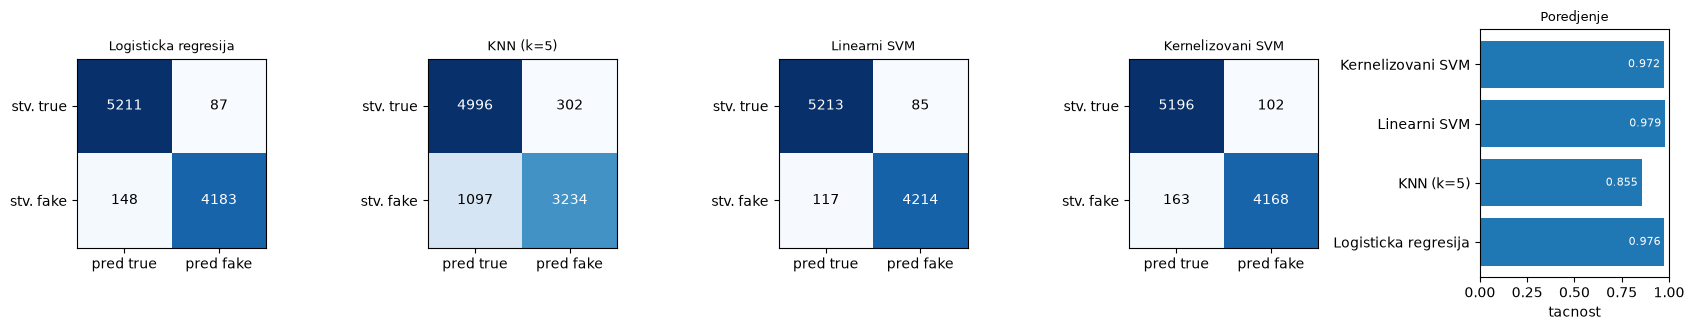

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

redovi = []
for naziv, pred in predikcije_klasicne.items():
    prec, rec, f1, _ = precision_recall_fscore_support(
        yk_test, pred, average="binary", zero_division=0)
    redovi.append({"model": naziv, "accuracy": rezultati_klasicni[naziv],
                   "precision": prec, "recall": rec, "f1": f1})

tabela_klasicni = pd.DataFrame(redovi).set_index("model").round(4)
print(tabela_klasicni.sort_values("f1", ascending=False))

fig, axes = plt.subplots(1, len(predikcije_klasicne) + 1,
                         figsize=(3.4 * (len(predikcije_klasicne) + 1), 3.4))

for ax, (naziv, pred) in zip(axes, predikcije_klasicne.items()):
    cm = confusion_matrix(yk_test, pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(naziv, fontsize=9)
    ax.set_xticks([0, 1], ["pred true", "pred fake"])
    ax.set_yticks([0, 1], ["stv. true", "stv. fake"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

axes[-1].barh(list(rezultati_klasicni.keys()), list(rezultati_klasicni.values()))
axes[-1].set_xlim(0, 1)
axes[-1].set_xlabel("tacnost")
axes[-1].set_title("Poredjenje", fontsize=9)
for i, v in enumerate(rezultati_klasicni.values()):
    axes[-1].text(v - 0.02, i, f"{v:.3f}", va="center", ha="right",
                  color="white", fontsize=8)

plt.tight_layout()
plt.show()


## Tokenizacija i podela na skupove


In [12]:
!pip install scikit-learn

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

tf.keras.utils.set_random_seed(SEME)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(df.text_ok, df.label, stratify = df.label, random_state=42)

tok = Tokenizer(num_words = 3000, oov_token = "<OOV>")


tok.fit_on_texts(X_train)

Xtre = pad_sequences(tok.texts_to_sequences(X_train), 300, truncating="post")
Xpre = pad_sequences(tok.texts_to_sequences(X_test), 300, truncating="post")


## CNN model


In [14]:

from tensorflow.keras import layers, models

cnn = models.Sequential([
    layers.Embedding(3000, 128, input_length=300),
    layers.Conv1D(128, 5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

C:\Users\bogda\miniconda3\envs\ml\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## LSTM model


In [15]:
lstm = models.Sequential([
    layers.Embedding(3000, 128, input_length=300),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

## Treniranje


In [16]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
hist = cnn.fit(Xtre, y_train, validation_split=0.1, epochs=10, batch_size=64, callbacks=[es], verbose=2)

Epoch 1/10


407/407 - 117s - 288ms/step - accuracy: 0.9169 - loss: 0.1778 - val_accuracy: 0.9858 - val_loss: 0.0348


Epoch 2/10


407/407 - 56s - 139ms/step - accuracy: 0.9865 - loss: 0.0393 - val_accuracy: 0.9848 - val_loss: 0.0389


Epoch 3/10


...

407/407 - 142s - 349ms/step - accuracy: 0.9965 - loss: 0.0103 - val_accuracy: 0.9920 - val_loss: 0.0264


Epoch 6/10


407/407 - 96s - 237ms/step - accuracy: 0.9968 - loss: 0.0096 - val_accuracy: 0.9920 - val_loss: 0.0322


Epoch 7/10


407/407 - 124s - 305ms/step - accuracy: 0.9975 - loss: 0.0083 - val_accuracy: 0.9893 - val_loss: 0.0374


## Hibridni model: 1D CNN + LSTM


In [17]:
hibrid = models.Sequential([
    layers.Input(shape=(300,)),
    layers.Embedding(3000, 128),
    layers.Conv1D(128, 5, activation="relu"),
    layers.MaxPooling1D(4),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

hibrid.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hibrid.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 128)       │       384,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 296, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,521 (1.97 MB)

 Trainable params: 515,521 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

### Treniranje hibrida


In [18]:
es_hibrid = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

hist_hibrid = hibrid.fit(Xtre, y_train, validation_split=0.1,
                         epochs=10, batch_size=64, callbacks=[es_hibrid], verbose=2)


Epoch 1/10


407/407 - 78s - 191ms/step - accuracy: 0.9157 - loss: 0.1968 - val_accuracy: 0.9848 - val_loss: 0.0462


Epoch 2/10


407/407 - 163s - 401ms/step - accuracy: 0.9877 - loss: 0.0436 - val_accuracy: 0.9875 - val_loss: 0.0403


Epoch 3/10


407/407 - 134s - 329ms/step - accuracy: 0.9917 - loss: 0.0287 - val_accuracy: 0.9872 - val_loss: 0.0420


Epoch 4/10


407/407 - 170s - 417ms/step - accuracy: 0.9954 - loss: 0.0160 - val_accuracy: 0.9868 - val_loss: 0.0520


## Dotreniranje transformera


In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

MODEL = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256, padding="max_length")

args = TrainingArguments(
    output_dir="out", num_train_epochs=2, learning_rate=2e-5,
    per_device_train_batch_size=32, eval_strategy="epoch")

C:\Users\bogda\miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1654.05it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Testovi i rezultati


### 2. Pomocne funkcije za evaluaciju


In [20]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

rezultati = {}
verovatnoce = {}
istinite = {}


def oceni(naziv, y_true, y_prob, prag=0.5, ispis=True):
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob >= prag).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")

    rezultati[naziv] = {"accuracy": acc, "precision": prec,
                        "recall": rec, "f1": f1, "roc_auc": auc}
    verovatnoce[naziv] = y_prob
    istinite[naziv] = y_true

    if ispis:
        print(naziv)
        print(classification_report(y_true, y_pred,
                                    target_names=["prava", "lazna"],
                                    digits=4, zero_division=0))
    return rezultati[naziv]


def matrica_konfuzije(ax, y_true, y_pred, naslov):
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(naslov, fontsize=9)
    ax.set_xticks([0, 1], ["pred prava", "pred lazna"])
    ax.set_yticks([0, 1], ["prava", "lazna"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    return cm


print("test skup:", len(y_test))
print(pd.Series(np.asarray(y_test)).value_counts())


test skup: 9629
0    5298
1    4331
Name: count, dtype: int64


### 3. Treniranje LSTM-a


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

es_lstm = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
hist_lstm = lstm.fit(Xtre, y_train, validation_split=0.1,
                     epochs=10, batch_size=64, callbacks=[es_lstm], verbose=2)


Epoch 1/10


407/407 - 373s - 916ms/step - accuracy: 0.8742 - loss: 0.3134 - val_accuracy: 0.9720 - val_loss: 0.0960


Epoch 2/10


407/407 - 333s - 818ms/step - accuracy: 0.9725 - loss: 0.0904 - val_accuracy: 0.9765 - val_loss: 0.0795


Epoch 3/10


...

407/407 - 205s - 503ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9893 - val_loss: 0.0463


Epoch 8/10


407/407 - 333s - 819ms/step - accuracy: 0.9958 - loss: 0.0149 - val_accuracy: 0.9868 - val_loss: 0.0502


Epoch 9/10


407/407 - 208s - 511ms/step - accuracy: 0.9963 - loss: 0.0124 - val_accuracy: 0.9882 - val_loss: 0.0536


### 4. Rezultati na test skupu


In [22]:
y_true = np.asarray(y_test)

oceni("CNN", y_true, cnn.predict(Xpre, verbose=0))
oceni("BiLSTM", y_true, lstm.predict(Xpre, verbose=0))
oceni("CNN + LSTM (hibrid)", y_true, hibrid.predict(Xpre, verbose=0))

pd.DataFrame(rezultati).T.round(4)


CNN
              precision    recall  f1-score   support

       prava     0.9870    0.9926    0.9898      5298
       lazna     0.9909    0.9841    0.9875      4331

    accuracy                         0.9888      9629
   macro avg     0.9890    0.9884    0.9887      9629
weighted avg     0.9888    0.9888    0.9888      9629



BiLSTM
              precision    recall  f1-score   support

       prava     0.9906    0.9896    0.9901      5298
       lazna     0.9873    0.9885    0.9879      4331

    accuracy                         0.9891      9629
   macro avg     0.9889    0.9890    0.9890      9629
weighted avg     0.9891    0.9891    0.9891      9629



CNN + LSTM (hibrid)
              precision    recall  f1-score   support

       prava     0.9930    0.9906    0.9918      5298
       lazna     0.9885    0.9915    0.9900      4331

    accuracy                         0.9910      9629
   macro avg     0.9907    0.9910    0.9909      9629
weighted avg     0.9910    0.9910    0.9910      9629



,accuracy,precision,recall,f1,roc_auc
CNN,0.9888,0.9909,0.9841,0.9875,0.9990
BiLSTM,0.9891,0.9873,0.9885,0.9879,0.9979
CNN + LSTM (hibrid),0.9910,0.9885,0.9915,0.9900,0.9985


### 5. Donja granica i osnovni TF-IDF


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
oceni("Dummy (vecinska klasa)", y_true, dummy.predict_proba(X_test)[:, 1])

tfidf_osnovni = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
tfidf_osnovni.fit(X_train, y_train)
oceni("TF-IDF+LogReg (osnovni)", y_true, tfidf_osnovni.predict_proba(X_test)[:, 1])

pd.DataFrame(rezultati).T.round(4)


Dummy (vecinska klasa)
              precision    recall  f1-score   support

       prava     0.5502    1.0000    0.7099      5298
       lazna     0.0000    0.0000    0.0000      4331

    accuracy                         0.5502      9629
   macro avg     0.2751    0.5000    0.3549      9629
weighted avg     0.3027    0.5502    0.3906      9629



TF-IDF+LogReg (osnovni)
              precision    recall  f1-score   support

       prava     0.9777    0.9870    0.9823      5298
       lazna     0.9839    0.9725    0.9782      4331

    accuracy                         0.9805      9629
   macro avg     0.9808    0.9797    0.9803      9629
weighted avg     0.9805    0.9805    0.9805      9629



,accuracy,precision,recall,f1,roc_auc
CNN,0.9888,0.9909,0.9841,0.9875,0.9990
BiLSTM,0.9891,0.9873,0.9885,0.9879,0.9979
CNN + LSTM (hibrid),0.9910,0.9885,0.9915,0.9900,0.9985
Dummy (vecinska klasa),0.5502,0.0000,0.0000,0.0000,0.5000
TF-IDF+LogReg (osnovni),0.9805,0.9839,0.9725,0.9782,0.9974


### 6. TF-IDF sa bigramima


In [24]:
from sklearn.model_selection import train_test_split

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    df.text_ok, df.label, stratify=df.label, random_state=42)

tfidf_text = make_pipeline(
    TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000))
tfidf_text.fit(Xt_train, yt_train)

oceni("TF-IDF+LogReg (bigrami)", np.asarray(yt_test),
      tfidf_text.predict_proba(Xt_test)[:, 1])

pd.DataFrame(rezultati).T.round(4).sort_values("f1", ascending=False)


TF-IDF+LogReg (bigrami)
              precision    recall  f1-score   support

       prava     0.9800    0.9892    0.9846      5298
       lazna     0.9867    0.9753    0.9810      4331

    accuracy                         0.9830      9629
   macro avg     0.9833    0.9823    0.9828      9629
weighted avg     0.9830    0.9830    0.9830      9629



,accuracy,precision,recall,f1,roc_auc
CNN + LSTM (hibrid),0.9910,0.9885,0.9915,0.9900,0.9985
BiLSTM,0.9891,0.9873,0.9885,0.9879,0.9979
CNN,0.9888,0.9909,0.9841,0.9875,0.9990
TF-IDF+LogReg (bigrami),0.9830,0.9867,0.9753,0.9810,0.9978
TF-IDF+LogReg (osnovni),0.9805,0.9839,0.9725,0.9782,0.9974
Dummy (vecinska klasa),0.5502,0.0000,0.0000,0.0000,0.5000


### 7. Matrice konfuzije i ROC krive


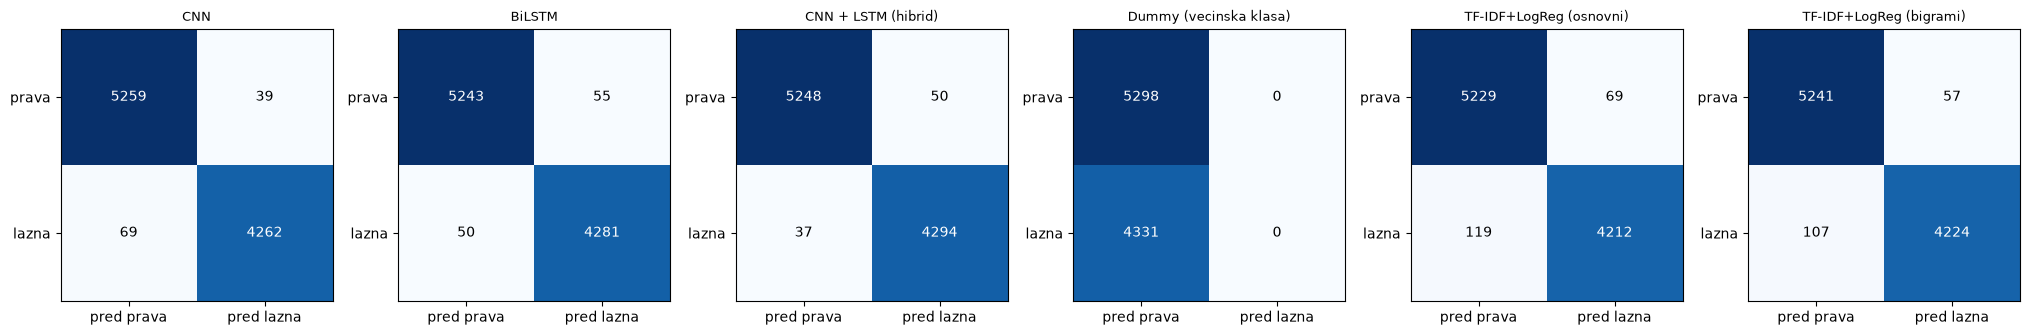

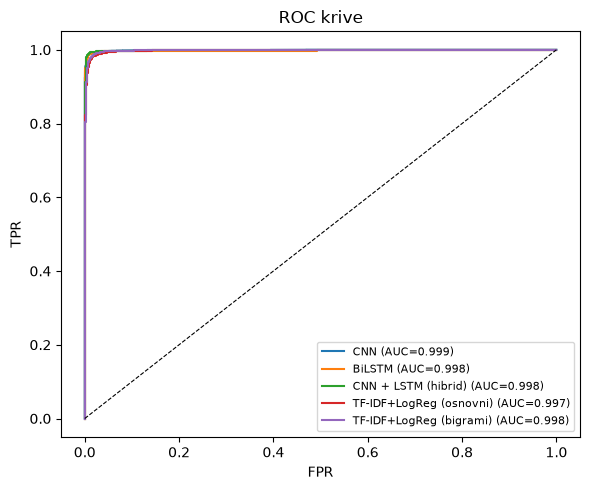

In [25]:
nazivi = list(verovatnoce.keys())

fig, axes = plt.subplots(1, len(nazivi), figsize=(3.4 * len(nazivi), 3.4))
axes = np.atleast_1d(axes)
for ax, naziv in zip(axes, nazivi):
    matrica_konfuzije(ax, istinite[naziv],
                      (verovatnoce[naziv] >= 0.5).astype(int), naziv)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
for naziv in nazivi:
    if len(np.unique(verovatnoce[naziv])) < 2:
        continue
    fpr, tpr, _ = roc_curve(istinite[naziv], verovatnoce[naziv])
    plt.plot(fpr, tpr, label=f"{naziv} (AUC={rezultati[naziv]['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC krive")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 8. Krive ucenja (provera overfita)


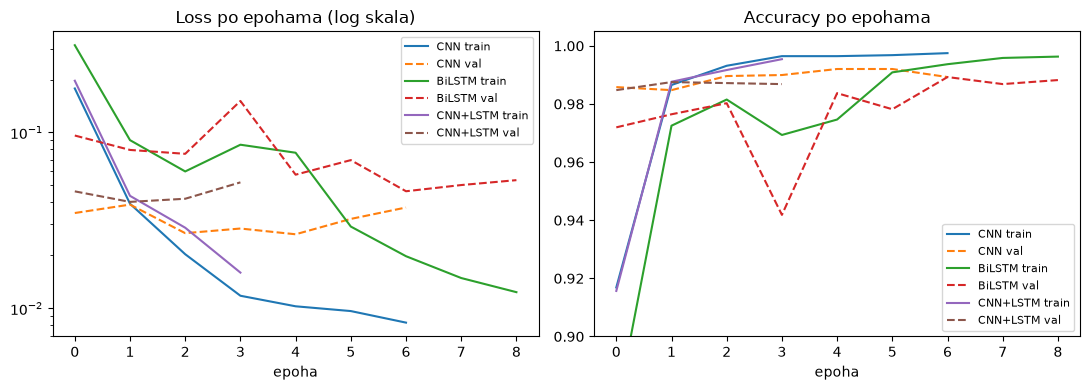

CNN | najbolja epoha: 5 od 7 | train: 0.0103 | val: 0.0264
BiLSTM | najbolja epoha: 7 od 9 | train: 0.0198 | val: 0.0463
CNN+LSTM | najbolja epoha: 2 od 4 | train: 0.0436 | val: 0.0403


In [26]:
istorije = {"CNN": hist, "BiLSTM": hist_lstm, "CNN+LSTM": hist_hibrid}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for naziv, h in istorije.items():
    axes[0].plot(h.history["loss"], label=naziv + " train")
    axes[0].plot(h.history["val_loss"], "--", label=naziv + " val")
    axes[1].plot(h.history["accuracy"], label=naziv + " train")
    axes[1].plot(h.history["val_accuracy"], "--", label=naziv + " val")

axes[0].set_yscale("log")
axes[0].set_title("Loss po epohama (log skala)")
axes[0].set_xlabel("epoha")
axes[0].legend(fontsize=8)
axes[1].set_ylim(0.9, 1.005)
axes[1].set_title("Accuracy po epohama")
axes[1].set_xlabel("epoha")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for naziv, h in istorije.items():
    vl = h.history["val_loss"]
    tl = h.history["loss"]
    naj = int(np.argmin(vl))

    print(naziv,
          "| najbolja epoha:", naj + 1, "od", len(vl),
          "| train:", round(tl[naj], 4),
          "| val:", round(vl[naj], 4))


### 9. test protiv test_ok


In [27]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

varijante = {"originalni text": "text", "ocisceni text_ok": "text_ok"}
poredjenje = []
modeli_cena = {}

for opis, kol in varijante.items():
    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
        df[kol], df.label, stratify=df.label, random_state=42)

    vek = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
    Xa_tr_v = vek.fit_transform(Xa_tr)
    Xa_te_v = vek.transform(Xa_te)

    red = {"varijanta": opis}
    for ime_m, m in (("LogReg", LogisticRegression(max_iter=1000)),
                     ("LinearSVC", LinearSVC())):
        m.fit(Xa_tr_v, ya_tr)
        red[ime_m] = accuracy_score(ya_te, m.predict(Xa_te_v))
        modeli_cena[(opis, ime_m)] = (m, vek)
    poredjenje.append(red)

tabela_artefakti = pd.DataFrame(poredjenje).set_index("varijanta").round(4)

print(tabela_artefakti)
print()
print("razlika:")
print((tabela_artefakti - tabela_artefakti.loc["originalni text"]).round(4))


                  LogReg  LinearSVC
varijanta                          
originalni text   0.9873     0.9952
ocisceni text_ok  0.9830     0.9916

razlika:
                  LogReg  LinearSVC
varijanta                          
originalni text   0.0000     0.0000
ocisceni text_ok -0.0043    -0.0036


### 10. Rezultati sa Colab-a


In [28]:
import os
import json

PUT = "rezultati_colab.json"
OCEKIVANO = len(df)

if os.path.exists(PUT):
    with open(PUT, encoding="utf-8") as f:
        rezultati_colab = json.load(f)

    n = rezultati_colab.pop("n_test", None)
    if n is not None and n != round(0.25 * OCEKIVANO):
        print("PAZNJA: Colab rezultati su na", n, "test primera, a ovde ih je",
              round(0.25 * OCEKIVANO))

    for ime in rezultati_colab:
        rezultati[ime] = rezultati_colab[ime]

    print("ucitano sa Colab-a:", len(rezultati_colab))
else:
    print("nema", PUT, "- pokreni colab_transformeri.ipynb")

pd.DataFrame(rezultati).T.round(4).sort_values("f1", ascending=False)


ucitano sa Colab-a: 3


,accuracy,precision,recall,f1,roc_auc
DistilBERT,0.9973,0.9981,0.9958,0.9970,0.9998
CNN + LSTM (hibrid),0.9910,0.9885,0.9915,0.9900,0.9985
BiLSTM,0.9891,0.9873,0.9885,0.9879,0.9979
CNN,0.9888,0.9909,0.9841,0.9875,0.9990
TF-IDF+LogReg (bigrami),0.9830,0.9867,0.9753,0.9810,0.9978
TF-IDF+LogReg (osnovni),0.9805,0.9839,0.9725,0.9782,0.9974
Embedinzi + LinearSVC,0.9464,0.9454,0.9349,0.9401,NaN
Embedinzi + LogReg,0.9400,0.9420,0.9233,0.9326,0.9839
Dummy (vecinska klasa),0.5502,0.0000,0.0000,0.0000,0.5000


### 11. Podesavanje hiperparametara


In [29]:
from sklearn.model_selection import GridSearchCV

Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    df["text_clean"], df["label"], test_size=0.25,
    stratify=df["label"], random_state=42)

vek_h = TfidfVectorizer(max_features=5000)
Ah = vek_h.fit_transform(Xh_tr)
Bh = vek_h.transform(Xh_te)

pretrage = {
    "KNN": (KNeighborsClassifier(), {"n_neighbors": [3, 5, 11, 21]}, 1),
    "Linearni SVM": (LinearSVC(), {"C": [0.1, 1, 10]}, -1),
    "Logisticka regresija": (LogisticRegression(max_iter=1000), {"C": [0.1, 1, 10]}, -1),
}

najbolji = {}

for ime, (model, mreza, niti) in pretrage.items():
    gs = GridSearchCV(model, mreza, cv=3, scoring="accuracy", n_jobs=niti)
    gs.fit(Ah, yh_tr)
    t = accuracy_score(yh_te, gs.predict(Bh))
    najbolji[ime] = {"parametri": gs.best_params_, "cv": gs.best_score_, "test": t}
    print("%-22s %-22s cv %.4f   test %.4f"
          % (ime, str(gs.best_params_), gs.best_score_, t))

KNN                    {'n_neighbors': 21}    cv 0.8570   test 0.8526


Linearni SVM           {'C': 1}               cv 0.9764   test 0.9790


Logisticka regresija   {'C': 10}              cv 0.9758   test 0.9801


### 12. Analiza gresaka


In [30]:
model_g = LinearSVC()
model_g.fit(Ah, yh_tr)
pred_g = model_g.predict(Bh)

pogresni = yh_te.index[pred_g != yh_te]
tacni = yh_te.index[pred_g == yh_te]

print("pogresnih:", len(pogresni), "od", len(yh_te))
print()
print("po stvarnoj klasi:")
print(df.loc[pogresni, "label"].value_counts().rename({0: "prava", 1: "lazna"}).to_string())
print()
print("duzina teksta:")
print("  pogresni  :", round(df.loc[pogresni, "duzina"].mean()), "znakova")
print("  tacni     :", round(df.loc[tacni, "duzina"].mean()), "znakova")
print()
print("po kategoriji:")
print(df.loc[pogresni, "subject"].value_counts().head(6).to_string())
print()
print("tri pogresno klasifikovana clanka:")
for idx in pogresni[:3]:
    stvarno = "lazna" if df.loc[idx, "label"] == 1 else "prava"
    print("  [stvarno %s]" % stvarno, df.loc[idx, "text_ok"][:150])

pogresnih: 202 od 9629

po stvarnoj klasi:
label
lazna    117
prava     85

duzina teksta:
  pogresni  : 2542 znakova
  tacni     : 2388 znakova

po kategoriji:


subject
politicsNews       68
politics           46
News               27
left-news          25
Government News    18
worldnews          17

tri pogresno klasifikovana clanka:
  [stvarno lazna] Whether federal spending legislation crosses the line from enticement to coercion is often difficult to determine, and courts should not conclude that
  [stvarno prava] Alphabet Inc s Google in the last few months has begun removing from YouTube extremist videos that do not depict violence or preach hate, YouTube said
  [stvarno lazna] President Trump arrived like a boss to check out what s going on at the NATO headquarters. They just spent big bucks on a new headquarters Trump s pro


### 13. Generalizacija na druge kategorije


In [31]:
TRENING_KAT = ["politicsNews", "News"]
TEST_KAT = ["worldnews", "politics"]

tr = df[df["subject"].isin(TRENING_KAT)]
te = df[df["subject"].isin(TEST_KAT)]

print("trening:", len(tr), dict(tr["label"].value_counts()))
print("test   :", len(te), dict(te["label"].value_counts()))
print()

vek_s = TfidfVectorizer(max_features=5000)
As = vek_s.fit_transform(tr["text_clean"])
Bs = vek_s.transform(te["text_clean"])

for ime, m in (("Linearni SVM", LinearSVC()),
               ("Logisticka regresija", LogisticRegression(max_iter=1000))):
    m.fit(As, tr["label"])
    print("%-22s %.4f" % (ime, accuracy_score(te["label"], m.predict(Bs))))

print()
print("za poredjenje, isti modeli na obicnoj podeli:")
print("  Linearni SVM           0.9790")
print("  Logisticka regresija   0.9756")

trening: 20257 {0: np.int64(11207), 1: np.int64(9050)}
test   : 14240 {0: np.int64(9982), 1: np.int64(4258)}



Linearni SVM           0.9268


Logisticka regresija   0.9247

za poredjenje, isti modeli na obicnoj podeli:
  Linearni SVM           0.9790
  Logisticka regresija   0.9756


### 14. Sira pretraga hiperparametara

#### 14.1 Podela na trening, validacioni i test skup

In [3]:
import time
import warnings
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")

X_ostatak, X_test_h, y_ostatak, y_test_h = train_test_split(
    df["text_clean"], df["label"], test_size=0.2,
    stratify=df["label"], random_state=42)

X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(
    X_ostatak, y_ostatak, test_size=0.25,
    stratify=y_ostatak, random_state=42)

print("trening:   ", len(X_train_h))
print("validacija:", len(X_val_h))
print("test:      ", len(X_test_h))

trening:    23108
validacija: 7703
test:       7703


#### 14.2 Pretraga parametara TF-IDF vektorizatora

In [4]:
rezultati_vek = []

for max_f in [1000, 5000, 20000, 50000]:
    for ngram in [(1, 1), (1, 2)]:
        for min_df in [1, 5]:
            for sublinear in [False, True]:
                t0 = time.time()
                vek = TfidfVectorizer(max_features=max_f, ngram_range=ngram,
                                      min_df=min_df, sublinear_tf=sublinear)
                A = vek.fit_transform(X_train_h)
                B = vek.transform(X_val_h)
                m = LogisticRegression(max_iter=1000)
                m.fit(A, y_train_h)
                tr = accuracy_score(y_train_h, m.predict(A))
                va = accuracy_score(y_val_h, m.predict(B))
                rezultati_vek.append({"max_features": max_f, "ngram": "%d-%d" % ngram,
                                      "min_df": min_df, "sublinear_tf": sublinear,
                                      "trening": tr, "validacija": va,
                                      "sekundi": round(time.time() - t0, 1)})
                print("max_features %-6d ngram %d-%d  min_df %d  sublinear %-5s  trening %.4f  validacija %.4f"
                      % (max_f, ngram[0], ngram[1], min_df, sublinear, tr, va))

tabela_vek = pd.DataFrame(rezultati_vek).sort_values("validacija", ascending=False)
print()
print("najboljih 10 po validaciji:")
print(tabela_vek.head(10).to_string(index=False))

max_features 1000   ngram 1-1  min_df 1  sublinear False  trening 0.9698  validacija 0.9648


max_features 1000   ngram 1-1  min_df 1  sublinear True   trening 0.9723  validacija 0.9700


max_features 1000   ngram 1-1  min_df 5  sublinear False  trening 0.9698  validacija 0.9648


max_features 1000   ngram 1-1  min_df 5  sublinear True   trening 0.9723  validacija 0.9700


max_features 1000   ngram 1-2  min_df 1  sublinear False  trening 0.9738  validacija 0.9691


...

max_features 50000  ngram 1-2  min_df 1  sublinear False  trening 0.9848  validacija 0.9736


max_features 50000  ngram 1-2  min_df 1  sublinear True   trening 0.9881  validacija 0.9791


max_features 50000  ngram 1-2  min_df 5  sublinear False  trening 0.9846  validacija 0.9736


max_features 50000  ngram 1-2  min_df 5  sublinear True   trening 0.9881  validacija 0.9791

najboljih 10 po validaciji:


 max_features ngram  min_df  sublinear_tf  trening  validacija  sekundi
         5000   1-2       1          True 0.985546    0.980527     27.5
         5000   1-2       5          True 0.985546    0.980527     27.3
        20000   1-2       1          True 0.987407    0.980138     28.0
        20000   1-2       5          True 0.987450    0.980138     27.8
        50000   1-2       5          True 0.988143    0.979099     28.5
        50000   1-2       1          True 0.988143    0.979099     28.5
         5000   1-1       5          True 0.984032    0.977541     13.0
         5000   1-1       1          True 0.984032    0.977541     11.1
        50000   1-1       5          True 0.985243    0.976373      6.7
        20000   1-1       5          True 0.985243    0.976373      6.7


#### 14.3 Pretraga parametara logisticke regresije

In [5]:
najbolji_vek = tabela_vek.iloc[0]
ngrami = {"1-1": (1, 1), "1-2": (1, 2)}

vek = TfidfVectorizer(max_features=int(najbolji_vek["max_features"]),
                      ngram_range=ngrami[najbolji_vek["ngram"]],
                      min_df=int(najbolji_vek["min_df"]),
                      sublinear_tf=bool(najbolji_vek["sublinear_tf"]))
A = vek.fit_transform(X_train_h)
B = vek.transform(X_val_h)
print("broj obelezja:", A.shape[1])
print()

rezultati_klas = []

for C in [0.001, 0.01, 0.1, 1, 10, 100, 1000]:
    for penalty in ["l1", "l2"]:
        for tezine in [None, "balanced"]:
            t0 = time.time()
            m = LogisticRegression(C=C, penalty=penalty, class_weight=tezine,
                                   solver="liblinear", max_iter=1000)
            m.fit(A, y_train_h)
            tr = accuracy_score(y_train_h, m.predict(A))
            va = accuracy_score(y_val_h, m.predict(B))
            rezultati_klas.append({"C": C, "penalty": penalty, "class_weight": str(tezine),
                                   "trening": tr, "validacija": va,
                                   "sekundi": round(time.time() - t0, 1)})
            print("C %-7g penalty %s  class_weight %-8s  trening %.4f  validacija %.4f"
                  % (C, penalty, tezine, tr, va))

tabela_klas = pd.DataFrame(rezultati_klas).sort_values("validacija", ascending=False)
print()
print("najboljih 10 po validaciji:")
print(tabela_klas.head(10).to_string(index=False))

broj obelezja: 5000



C 0.001   penalty l1  class_weight None      trening 0.5502  validacija 0.5502
C 0.001   penalty l1  class_weight balanced  trening 0.5502  validacija 0.5502


C 0.001   penalty l2  class_weight None      trening 0.5540  validacija 0.5537
C 0.001   penalty l2  class_weight balanced  trening 0.9291  validacija 0.9295


C 0.01    penalty l1  class_weight None      trening 0.7722  validacija 0.7713


C 0.01    penalty l1  class_weight balanced  trening 0.8006  validacija 0.7959


...

C 100     penalty l2  class_weight balanced  trening 1.0000  validacija 0.9855


C 1000    penalty l1  class_weight None      trening 1.0000  validacija 0.9830


C 1000    penalty l1  class_weight balanced  trening 1.0000  validacija 0.9812


C 1000    penalty l2  class_weight None      trening 1.0000  validacija 0.9842


C 1000    penalty l2  class_weight balanced  trening 1.0000  validacija 0.9843

najboljih 10 po validaciji:
     C penalty class_weight  trening  validacija  sekundi
  10.0      l2     balanced 0.997880    0.985590      0.9
 100.0      l2     balanced 1.000000    0.985460      1.6
  10.0      l2         None 0.997706    0.985071      0.9
 100.0      l2         None 1.000000    0.985071      1.5
  10.0      l1         None 0.999351    0.984811      1.1
1000.0      l2     balanced 1.000000    0.984292      1.9
  10.0      l1     balanced 0.999394    0.984292      1.4
1000.0      l2         None 1.000000    0.984162      1.8
 100.0      l1         None 1.000000    0.982994      1.1
1000.0      l1         None 1.000000    0.982994      0.5


#### 14.4 Grafici

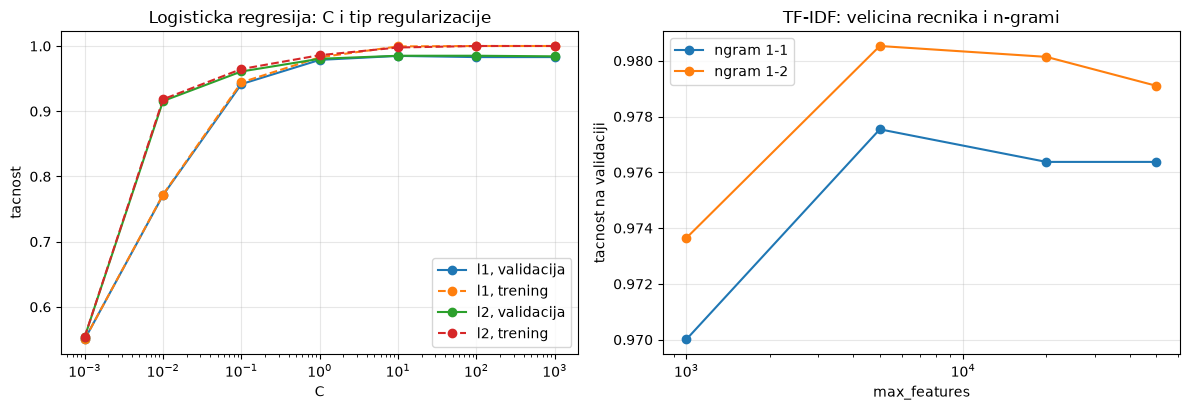

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for penalty in ["l1", "l2"]:
    deo = tabela_klas[(tabela_klas["penalty"] == penalty) & (tabela_klas["class_weight"] == "None")]
    deo = deo.sort_values("C")
    axes[0].plot(deo["C"], deo["validacija"], marker="o", label=penalty + ", validacija")
    axes[0].plot(deo["C"], deo["trening"], marker="o", linestyle="--", label=penalty + ", trening")
axes[0].set_xscale("log")
axes[0].set_xlabel("C")
axes[0].set_ylabel("tacnost")
axes[0].set_title("Logisticka regresija: C i tip regularizacije")
axes[0].legend()
axes[0].grid(alpha=0.3)

for ngram in ["1-1", "1-2"]:
    deo = tabela_vek[tabela_vek["ngram"] == ngram].groupby("max_features")["validacija"].max()
    axes[1].plot(deo.index, deo.values, marker="o", label="ngram " + ngram)
axes[1].set_xscale("log")
axes[1].set_xlabel("max_features")
axes[1].set_ylabel("tacnost na validaciji")
axes[1].set_title("TF-IDF: velicina recnika i n-grami")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 14.5 Najbolja kombinacija na test skupu

In [7]:
najbolji = tabela_klas.iloc[0]
if najbolji["class_weight"] == "None":
    tezine = None
else:
    tezine = "balanced"

m = LogisticRegression(C=najbolji["C"], penalty=najbolji["penalty"], class_weight=tezine,
                       solver="liblinear", max_iter=1000)
m.fit(A, y_train_h)
T = vek.transform(X_test_h)

print("najbolja kombinacija:")
print("  TF-IDF: max_features", int(najbolji_vek["max_features"]), " ngram", najbolji_vek["ngram"],
      " min_df", int(najbolji_vek["min_df"]), " sublinear_tf", bool(najbolji_vek["sublinear_tf"]))
print("  LogReg: C", najbolji["C"], " penalty", najbolji["penalty"], " class_weight", najbolji["class_weight"])
print()
print("trening    %.4f" % accuracy_score(y_train_h, m.predict(A)))
print("validacija %.4f" % accuracy_score(y_val_h, m.predict(B)))
print("test       %.4f" % accuracy_score(y_test_h, m.predict(T)))
print()

vek0 = TfidfVectorizer(max_features=5000)
A0 = vek0.fit_transform(X_train_h)
m0 = LogisticRegression(max_iter=1000)
m0.fit(A0, y_train_h)
print("podrazumevani model, max_features 5000 i C 1, na istom testu:")
print("test       %.4f" % accuracy_score(y_test_h, m0.predict(vek0.transform(X_test_h))))

najbolja kombinacija:
  TF-IDF: max_features 5000  ngram 1-2  min_df 1  sublinear_tf True
  LogReg: C 10.0  penalty l2  class_weight balanced

trening    0.9979
validacija 0.9856
test       0.9860



podrazumevani model, max_features 5000 i C 1, na istom testu:


test       0.9740
